In [1]:
# ============================================================
# SETUP PATHS & IMPORTS (Ported from Siamese)
# ============================================================
import sys, os, warnings, logging, random
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["ABSL_LOG_LEVEL"] = "3"

# ============================================================
# 1. LOCAL DYNAMIC PATH ROUTING
# ============================================================
current_dir = os.getcwd()
workspace_root = current_dir
if os.path.basename(current_dir) == "notebooks":
    workspace_root = os.path.dirname(current_dir)
src_path = os.path.join(workspace_root, "src")
sys.path.insert(0, workspace_root)
sys.path.insert(0, src_path)

# ============================================================
# 2. KAGGLE SPECIFIC PATH ROUTING (Copied from Siamese)
# ============================================================
try:
    dataset_name = os.listdir("/kaggle/input/datasets/keithmarange")[0]
    sys.path.append(f"/kaggle/input/datasets/keithmarange/{dataset_name}/")
    sys.path.append("/kaggle/input/cmi-competition-code/")
except Exception:
    pass

import tensorflow as tf
tf.get_logger().setLevel("ERROR")

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV, GroupShuffleSplit
from sklearn.metrics import f1_score, make_scorer, classification_report

try:
    from skopt import BayesSearchCV
    from skopt.space import Categorical, Integer, Real
    SKOPT_AVAILABLE = True
except ImportError:
    SKOPT_AVAILABLE = False

# ============================================================
# 3. IMPORTS WITH ROBUST FALLBACK
# ============================================================
try:
    from src import data_utils
    from src.base_utils_qwen import SequenceExtractor, competition_scorer, evaluate_holdout, prepare_bayesian_space
    from src.multibranch_v1 import KerasFlexibleMultiBranchClassifier, FeatureAwarePipeline
    print("✅ Imports loaded from src/")
except ImportError:
    try:
        import data_utils
        from base_utils_qwen import SequenceExtractor, competition_scorer, evaluate_holdout, prepare_bayesian_space
        from multibranch_v1 import KerasFlexibleMultiBranchClassifier, FeatureAwarePipeline
        print("✅ Imports loaded flattened")
    except ImportError as e:
        print(f"❌ Import failed: {e}")
        print(f"Current directory: {os.getcwd()}")
        print(f"Files in current directory: {os.listdir('.')}")
        print(f"Files in src/ (if exists): {os.listdir('src') if os.path.exists('src') else 'src/ not found'}")
        raise

✅ Imports loaded flattened


In [2]:
# ============================================================
# CONFIGURATION & DATA LOADING
# ============================================================
TARGET_COL = "bfrb" # or "gesture_action"
pipe_name = "extractor"
clf_name = "classifier"

search_mode = "grid" 
random_state = 42
n_splits = 3
n_iter = 15
train_size = 0.4
error_score_constant = 'raise'
verbose = 3
do_cross_val = False


In [3]:
if do_cross_val:
    cv_object = GroupKFold(n_splits=n_splits)
else:
    cv_object = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)

scorer = competition_scorer
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# Load Data
data_root = data_utils.find_data_root()
raw_train_df = pd.read_csv(data_root / "train.csv")
train_df = raw_train_df.set_index("row_id").copy()

# Target Engineering
train_df["gesture_action"] = train_df["gesture"].str.split(" - ").str[-1]
train_df["orientation"] = train_df["orientation"].fillna("Unknown")
train_df["is_target"] = train_df["sequence_type"].eq("Target").astype(int)

# CRITICAL FIX: Create the 'bfrb' column if needed
if TARGET_COL == "bfrb":
    train_df["bfrb"] = train_df["gesture"].where(train_df["is_target"].astype(bool), "non_bfrb")

# Split with Fallback
try:
    train_sample_df, hold_out_df = data_utils.sample_balanced_split(
        train_df, train_pct=train_size, test_pct=max(0.2, 1 - train_size), random_state=random_state
    )
except ValueError as exc:
    print(f"Balanced split unavailable ({exc}); using simple sequence split.")
    unique_seqs = train_df[["sequence_id", TARGET_COL]].drop_duplicates("sequence_id").sample(frac=1, random_state=random_state)
    n_train = max(1, int(len(unique_seqs) * train_size))
    train_seqs = unique_seqs.iloc[:n_train]["sequence_id"]
    test_seqs = unique_seqs.iloc[n_train:]["sequence_id"]
    train_sample_df = train_df[train_df["sequence_id"].isin(train_seqs)].copy()
    hold_out_df = train_df[train_df["sequence_id"].isin(test_seqs)].copy()

X_train, X_test = train_sample_df, hold_out_df
y_train = X_train[["sequence_id", "is_target", TARGET_COL]].copy()
y_test  = X_test[["sequence_id", "is_target", TARGET_COL]].copy()
groups = X_train["sequence_id"]

print(f"Train sequences: {X_train['sequence_id'].nunique()} | Test sequences: {X_test['sequence_id'].nunique()}")

✅ Using Kaggle data folder: /kaggle/input/competitions/cmi-detect-behavior-with-sensor-data
Train: 2910 seqs | 35.7%
Test:  2881 seqs  | 35.3%
Train sequences: 2910 | Test sequences: 2881


In [4]:
# ============================================================
# PIPELINE SETUP
# ============================================================

pipeline = FeatureAwarePipeline([
    (pipe_name, SequenceExtractor(
        acc_modes="raw|velocity|jerk",

    )),
    (clf_name, KerasFlexibleMultiBranchClassifier(
        primary_target=TARGET_COL,
        verbose=0
    ))
])

In [5]:
if search_mode == "bayesian" and SKOPT_AVAILABLE:
    param_space = {
        # --- EXTRACTOR: Physics & Preprocessing ---
        f"{pipe_name}__acc_modes": Categorical(["raw|velocity|jerk", "smoothed|velocity|displacement|jerk"]),
        f"{pipe_name}__rotation_modes": Categorical(["quaternion|angular_velocity", "quaternion|euler|angular_velocity"]),
        f"{pipe_name}__tof_modes": Categorical(["pooled_stats", "sensor_stats"]),
        f"{pipe_name}__thm_modes": Categorical(["centered_diff", "diff"]),
        f"{pipe_name}__motion_filter_mode": Categorical(["extended_kalman", "kalman", None]),
        f"{pipe_name}__use_dead_reckoning": Categorical([True, False]),
        f"{pipe_name}__dead_reckoning_detrend": Categorical([True, False]),
        f"{pipe_name}__interp_mode": Categorical(["linear", "ffill"]),
        f"{pipe_name}__clip_value": Categorical([None, 50.0]),
        
        # --- FIXED: Replaced obsolete 'maxlen' with active chunking parameters ---
        f"{pipe_name}__chunk_window_size": Integer(64, 200),
        f"{pipe_name}__chunk_stride": Integer(16, 100),
        
        f"{pipe_name}__imu_target_sampling_rate": Categorical([50, 100]),
        f"{pipe_name}__rot_target_sampling_rate": Categorical([50, 100]),
        f"{pipe_name}__tof_target_sampling_rate": Categorical([10, 20]),
        f"{pipe_name}__thm_target_sampling_rate": Categorical([10, 20]),
        f"{pipe_name}__kalman_process_noise": Real(1e-5, 1e-1, prior="log-uniform"),
        f"{pipe_name}__kalman_measurement_noise": Real(1e-3, 1.0, prior="log-uniform"),
        f"{pipe_name}__smooth_alpha": Real(0.1, 0.9),
        
        # --- CLASSIFIER: Backbone & Architecture ---
        f"{clf_name}__backbone_type": Categorical(["1dcnn", "2dcnn", "attention", "gru"]),
        f"{clf_name}__branch_filters": Categorical([
            '{"acc": "64-128", "rot": "64", "thm": "16", "tof": "32"}',
            '{"acc": "128-256-256", "rot": "64-128", "thm": "16", "tof": "64"}',
            '{"acc": "256-512", "rot": "128-256", "thm": "32", "tof": "128"}'
        ]),
        f"{clf_name}__branch_kernel_sizes": Categorical([
            '{"acc": "5-5", "rot": "5", "thm": "3", "tof": "3"}',
            '{"acc": "3-3-3", "rot": "3-3", "thm": "3", "tof": "3"}'
        ]),
        f"{clf_name}__attention_heads": Integer(2, 8),
        f"{clf_name}__gru_units": Integer(64, 256),
        
        # --- CLASSIFIER: SE Fusion & Post-BiGRU ---
        f"{clf_name}__se_ratio": Integer(2, 8),
        f"{clf_name}__use_post_bigru": Categorical([True, False]),
        f"{clf_name}__post_gru_units": Integer(64, 256),
        f"{clf_name}__use_batch_norm": Categorical([True, False]),
        
        # --- CLASSIFIER: Training Dynamics & Regularization ---
        f"{clf_name}__spatial_dropout": Real(0.05, 0.3),
        f"{clf_name}__dropout": Real(0.1, 0.5),
        f"{clf_name}__learning_rate": Real(1e-4, 1e-2, prior="log-uniform"),
        f"{clf_name}__batch_size": Categorical([16, 32]),
        f"{clf_name}__epochs": Categorical([60, 100]),
        f"{clf_name}__patience": Categorical([10, 15])
    }
else: # Grid Search
    param_space = {
        f"{pipe_name}__acc_modes": ["smoothed|velocity|jerk"],
        f"{pipe_name}__rotation_modes": ["quaternion|angular_velocity"],
        f"{pipe_name}__tof_modes": ["pooled_stats"],
        f"{pipe_name}__thm_modes": ["centered_diff"],
        f"{pipe_name}__motion_filter_mode": ["extended_kalman"],
        f"{pipe_name}__use_dead_reckoning": [True],
        
        # --- FIXED: Replaced obsolete 'maxlen' with active chunking parameters ---
        f"{pipe_name}__chunk_window_size": [160],
        f"{pipe_name}__chunk_stride": [120],

        f"{pipe_name}__padding_value": [0.0],
        
        f"{pipe_name}__imu_target_sampling_rate": [100],
        f"{pipe_name}__rot_target_sampling_rate": [100],
        f"{pipe_name}__tof_target_sampling_rate": [10],
        f"{pipe_name}__thm_target_sampling_rate": [10],
        
        f"{clf_name}__backbone_type": ['1dcnn', "attention", "gru", "2dcnn"], 
        f"{clf_name}__branch_filters": ['{"acc": "128-128-128", "rot": "64-64-128", "thm": "16", "tof": "64-64"}'],
        f"{clf_name}__branch_kernel_sizes": ['{"acc": "3-3-3", "rot": "3-3-3", "thm": "3", "tof": "3-3"}'],
        f"{clf_name}__se_ratio": [4],
        f"{clf_name}__use_post_bigru": [True],
        f"{clf_name}__post_gru_units": [128],
        f"{clf_name}__use_batch_norm": [True],
        f"{clf_name}__dropout": [0.0],
        f"{clf_name}__learning_rate": [5e-3],
        f"{clf_name}__batch_size": [32],
        f"{clf_name}__epochs": [100],
        f"{clf_name}__patience": [10]
    }

In [6]:
# ============================================================
# SEARCH EXECUTION
# ============================================================
if search_mode == "bayesian" and SKOPT_AVAILABLE:
    search = BayesSearchCV(
        estimator=pipeline, search_spaces=param_space, n_iter=n_iter,
        scoring=competition_scorer, cv=cv_object, n_jobs=1,
        random_state=random_state, verbose=verbose, refit=True,
        return_train_score=True, error_score=error_score_constant
    )
else:
    search = GridSearchCV(
        estimator=pipeline, param_grid=param_space, scoring=competition_scorer,
        cv=cv_object, n_jobs=1, verbose=verbose, refit=True,
        return_train_score=True, error_score=error_score_constant
    )

print(f"🚀 Running {search_mode} search...")
# Passing 1D y_train array to satisfy sklearn CV requirements
search.fit(X_train, y_train, groups=groups)

print(f"\n🏆 Best CV competition score: {search.best_score_:.4f}")
print("Best parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
    
best_model = search.best_estimator_

🚀 Running grid search...
Fitting 1 folds for each of 4 candidates, totalling 4 fits


I0000 00:00:1784688354.004230      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784688354.010673      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


[CV 1/1] END classifier__backbone_type=1dcnn, classifier__batch_size=32, classifier__branch_filters={"acc": "128-128-128", "rot": "64-64-128", "thm": "16", "tof": "64-64"}, classifier__branch_kernel_sizes={"acc": "3-3-3", "rot": "3-3-3", "thm": "3", "tof": "3-3"}, classifier__dropout=0.0, classifier__epochs=100, classifier__learning_rate=0.005, classifier__patience=10, classifier__post_gru_units=128, classifier__se_ratio=4, classifier__use_batch_norm=True, classifier__use_post_bigru=True, extractor__acc_modes=smoothed|velocity|jerk, extractor__chunk_stride=120, extractor__chunk_window_size=160, extractor__imu_target_sampling_rate=100, extractor__motion_filter_mode=extended_kalman, extractor__padding_value=0.0, extractor__rot_target_sampling_rate=100, extractor__rotation_modes=quaternion|angular_velocity, extractor__thm_modes=centered_diff, extractor__thm_target_sampling_rate=10, extractor__tof_modes=pooled_stats, extractor__tof_target_sampling_rate=10, extractor__use_dead_reckoning=Tru

🚀 Analyzing Best Model & Evaluating on Holdout Set...
📈 Plotting Training & Validation Curves...



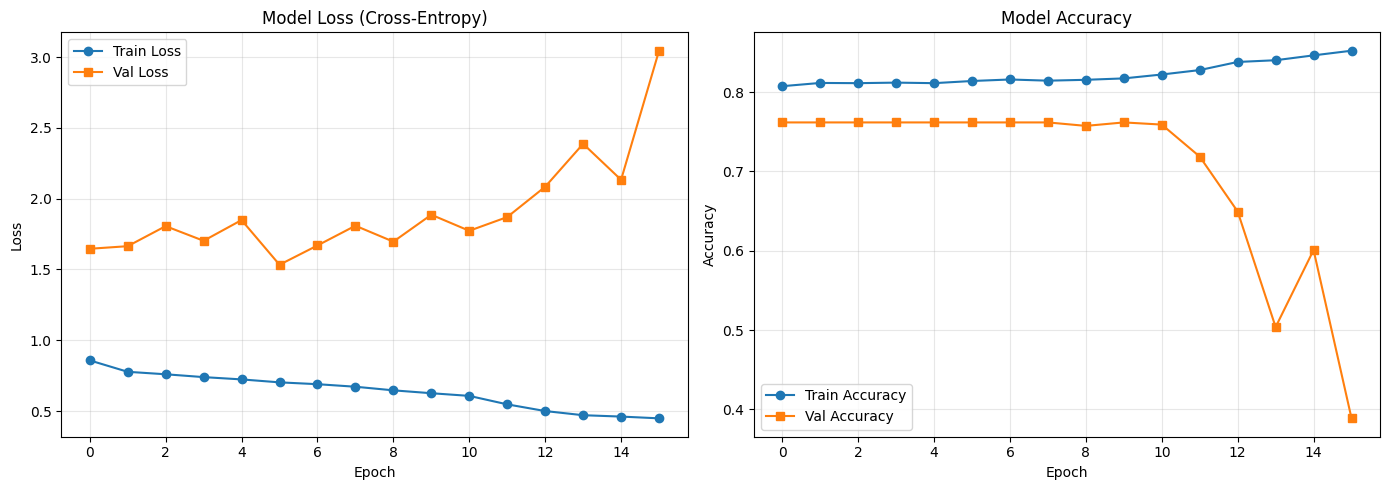

In [7]:
# ============================================================
# MODEL ANALYSIS, TRAINING CURVES & HOLDOUT EVALUATION
# ============================================================
print("🚀 Analyzing Best Model & Evaluating on Holdout Set...")

# 1. Extract the best fitted pipeline
best_pipeline = search.best_estimator_
best_classifier = best_pipeline.named_steps['classifier']

# 2. Plot Training & Validation Curves
if hasattr(best_classifier, 'history_'):
    print("📈 Plotting Training & Validation Curves...\n")
    history = best_classifier.history_
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss Curve
    axes[0].plot(history['loss'], label='Train Loss', marker='o')
    if 'val_loss' in history:
        axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_title('Model Loss (Cross-Entropy)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy Curve
    acc_key = 'accuracy' if 'accuracy' in history else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history else 'val_acc'
    
    axes[1].plot(history[acc_key], label='Train Accuracy', marker='o')
    if val_acc_key in history:
        axes[1].plot(history[val_acc_key], label='Val Accuracy', marker='s')
    axes[1].set_title('Model Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No training history found. Ensure `self.history_` is saved in the classifier's fit method.")


In [8]:
# 3. Print Model Architecture Summary (Essential for Tuning)
print("\n" + "="*70)
print("BEST MODEL ARCHITECTURE SUMMARY (Check layer shapes & parameter counts)")
print("="*70)
best_classifier.model_.summary()


BEST MODEL ARCHITECTURE SUMMARY (Check layer shapes & parameter counts)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ main_input          │ (None, 160, 144)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ acc_slice (Lambda)  │ (None, 160, 96)   │          0 │ main_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rot_slice (Lambda)  │ (None, 160, 12)   │          0 │ main_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_4 │ (None, 160, 96)   │          0 │ acc_slice[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask        │ (None, 160)       │          0 │ main_input[0][0]  │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_5 │ (None, 160, 12)   │          0 │ rot_slice[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 160, 128)  │     36,992 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding_mask_float  │ (None, 160, 1)    │          0 │ padding_mask[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 160, 64)   │      2,368 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_70         │ (None, 160, 128)  │          0 │ conv1d_9[0][0],   │
│ (Multiply)          │                   │            │ padding_mask_flo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_76         │ (None, 160, 64)   │          0 │ conv1d_12[0][0],  │
│ (Multiply)          │                   │            │ padding_mask_flo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 128)  │        512 │ multiply_70[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 64)   │        256 │ multiply_76[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_71         │ (None, 160, 128)  │          0 │ batch_normalizat… │
│ (Multiply)          │                   │            │ padding_mask_flo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_77         │ (None, 160, 64)   │          0 │ batch_normalizat… │
│ (Multiply)          │                   │            │ padding_mask_flo… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tof_slice (Lambda)  │ (None, 160, 6)    │          0 │ main_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 160, 128)  │          0 │ multiply_71[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 160, 64)   │          0 │ multiply_77[0][0] │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,827,481 (6.97 MB)

 Trainable params: 608,637 (2.32 MB)

 Non-trainable params: 1,568 (6.12 KB)

 Optimizer params: 1,217,276 (4.64 MB)

In [9]:
# ============================================================
# 4. HOLDOUT EVALUATION (With Robust Sequence Alignment)
# ============================================================
print("\n" + "="*70)
print("HOLDOUT EVALUATION")
print("="*70)

y_pred_raw = best_pipeline.predict(X_test)

# --- ROBUST ALIGNMENT FIX ---
# If the pipeline returned row-level predictions (len matches X_test rows),
# collapse them to sequence-level by taking the first prediction per sequence_id.
n_unique_seqs = X_test['sequence_id'].nunique()

if len(y_pred_raw) == len(X_test):
    print(f"⚠️ Pipeline returned {len(y_pred_raw)} row-level predictions. Collapsing to {n_unique_seqs} sequences...")
    pred_series = pd.Series(y_pred_raw, index=X_test.index)
    y_pred = X_test.assign(__pred=pred_series).drop_duplicates('sequence_id').sort_values('sequence_id')['__pred'].values
elif len(y_pred_raw) == n_unique_seqs:
    y_pred = y_pred_raw
else:
    raise ValueError(f"Cannot align predictions. y_pred has {len(y_pred_raw)} elements, but X_test has {n_unique_seqs} sequences and {len(X_test)} rows.")

# Evaluate using the aligned sequence-level predictions
eval_results = evaluate_holdout(
    y_test_df=X_test, 
    y_pred=y_pred, 
    target_col=TARGET_COL, 
    verbose=True
)

print(f"\n🎯 Final Holdout Competition Score: {eval_results['competition_score']:.4f}")

# Save results
holdout_results_path = results_dir / f"holdout_predictions_sota_{timestamp}.csv"
eval_results['results_df'].to_csv(holdout_results_path, index=False)
print(f"✅ Holdout sequence-level predictions saved to: {holdout_results_path}")


HOLDOUT EVALUATION

FINAL EVALUATION
Binary F1 (non_bfrb vs bfrb): 0.0021
BFRB Gesture Macro F1: 0.0000
COMPETITION SCORE: 0.0010

----------------------------------------
BFRB Gesture Classification Report
----------------------------------------
                          precision    recall  f1-score   support

   Above ear - pull hair       0.00      0.00      0.00     241.0
      Cheek - pinch skin       0.00      0.00      0.00     241.0
     Eyebrow - pull hair       0.00      0.00      0.00     241.0
     Eyelash - pull hair       0.00      0.00      0.00     241.0
Forehead - pull hairline       0.00      0.00      0.00     241.0
      Forehead - scratch       0.00      0.00      0.00     241.0
       Neck - pinch skin       0.00      0.00      0.00     241.0
          Neck - scratch       0.00      0.00      0.00     241.0
                non_bfrb       0.00      0.00      0.00       0.0

                accuracy                           0.00    1928.0
               macro av

In [10]:
# 5. Save All Results to Disk
# A. Full CV Results
cv_results_df = pd.DataFrame(search.cv_results_)
cv_results_path = results_dir / f"multibranch_cv_results_{timestamp}.csv"
cv_results_df.to_csv(cv_results_path, index=False)

# B. Best Model Summary
best_summary = {
    "best_score": search.best_score_,
    "best_params": str(search.best_params_),
    "mean_fit_time": search.cv_results_['mean_fit_time'][search.best_index_],
    "mean_test_score": search.cv_results_['mean_test_score'][search.best_index_],
}
pd.DataFrame([best_summary]).to_csv(results_dir / f"multibranch_best_summary_{timestamp}.csv", index=False)

# C. Holdout Predictions
holdout_results_path = results_dir / f"multibranch_holdout_results_{timestamp}.csv"
eval_results["results_df"].to_csv(holdout_results_path, index=False)

print(f"\n✅ Full CV results saved to: {cv_results_path}")
print(f"✅ Best summary saved to: {results_dir / f'multibranch_best_summary_{timestamp}.csv'}")
print(f"✅ Holdout sequence-level predictions saved to: {holdout_results_path}")


✅ Full CV results saved to: results/multibranch_cv_results_20260722_0243.csv
✅ Best summary saved to: results/multibranch_best_summary_20260722_0243.csv
✅ Holdout sequence-level predictions saved to: results/multibranch_holdout_results_20260722_0243.csv
